<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #fff5ef; color: #003152;">

**Project:** When Weight Doesn’t Weigh the same on Everyone: Applying The Lancet’s Clinical Obesity Framework to Map Phenotypic Diagnostic Gaps in NHANES 2021–2023  
**Source:** National Health and Nutrition Examination Survey (NHANES), Aug 2021–Aug 2023 Cycle  
**Key Transformation:** Row Attrition and Structural Selection Bias Mitigation  
**Version:** 1.0  

---
**Technical Focus:** Extraction, harmonization, and systemic alignment of multi-tiered CDC survey files. It implements an intentional row-attrition pipeline ($N=11,933 \to 4,073$) that isolates working-age adults while controlling for non-random structural missingness  
**Key Goal:** Eradicate structural missingness and establish a foundational cohort for epidemiological modeling.

</div>

In [1]:
from IPython.display import display, Markdown, HTML
import os
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import missingno as msno
import pyarrow

### 🧪 Clinical Parameters ingestion
---

Implementing *The Lancet Diabetes & Endocrinology* Commission consensus framework on clinical obesity ([The Lancet, 2025](https://www.thelancet.com/journals/landia/article/PIIS2213-8587%2824%2900316-4/fulltext)) requires moving past single metrics like BMI. To evaluate the diverse spectrum of obesity, our ingestion pipeline organizes disparate survey data into four primary clinical domains:

1.  **Demographics and Baselines:** Baseline anthropometric parameters and vital physical exam variables.
2.  **Laboratory Biomarkers:** Blood-derived metabolic analytes, such as lipid profiles, glycohemoglobin, fasting plasma glucose, and hepatic transaminases.
3.  **End-Organ Damage & Comorbidities:** Key patient history markers for cardiovascular disease, liver conditions, chronic kidney disease, and diabetic diagnostic states.
4.  **Questionnaire-Related Items:** Extracting patient-reported behavioral inputs such as physical activity thresholds and active smoking status.

In [2]:
class Loader:
    """
    Pipeline class to batch-load, type-standardize, and consolidate NHANES SAS Transport (.XPT) files 
    into an unified cohort.
    """

    def __init__(self, target_files=None, data_folder="../sources/"):
        self.data_folder = data_folder
        self.target_files = target_files or [
            "DEMO_L", "BMX_L", "LUX_L", "ALB_CR_L", "HDL_L", "TRIGLY_L", "TCHOL_L", "CBC_L", "GHB_L", "GLU_L", 
            "BIOPRO_L", "BPQ_L", "BPXO_L", "DIQ_L", "KIQ_U_L", "SMQ_L", "MCQ_L", "DPQ_L", "RXQ_RX_L", "PAQ_L"
        ]

        # Core data structures to store state
        self.loaded_datasets = {}  # Map: file_prefix -> DataFrame
        self.metadata_storage = {} # Map: file_prefix -> column_labels dict
        self.master_df = None

    def batch_load(self, encoding="latin1"):
        """
        Reads local .xpt files, standardizes patient IDs, and stores metadata maps.
        """

        print("Starting batch-loading pipeline...")
        
        for file_prefix in self.target_files:
            file_name = f"{file_prefix}.xpt"
            file_path = os.path.join(self.data_folder, file_name)
                
            if os.path.exists(file_path):
                print(f"Reading local: {file_name}")
                df, meta = pyreadstat.read_xport(file_path, encoding=encoding)
                
                # Standardize SEQN (Respondent Sequence Number) for flawless multi-table joins
                if 'SEQN' in df.columns:
                    df['SEQN'] = df['SEQN'].astype(int)
                
                self.loaded_datasets[file_prefix] = df
                self.metadata_storage[file_prefix] = meta.column_names_to_labels
            else:
                print(f"Warning: File {file_name} not found in {self.data_folder}")
        
        return self
    
    def consolidate(self, anchor_file="DEMO_L"):
        """
        Execute a sequential left join anchored on demographics to preserve baseline data 
        and handle duplicate columns via safe source-specific suffixes.
        """
        if not self.loaded_datasets:
            raise ValueError("Execution Error: No dataframes have been loaded into memory yet.")
        
        if anchor_file not in self.loaded_datasets:
            raise KeyError(f"Critical Error: Anchor file '{anchor_file}' was not successfully loaded.")

        print(f"\nConsolidating cohorts... Anchoring on baseline demographics: {anchor_file}")
        
        # Initialize master cohort dataframe with baseline demographics
        self.master_df = self.loaded_datasets[anchor_file]

        # Iterate through remaining loaded files safely using dictionary key mapping
        for file_prefix, df in self.loaded_datasets.items():
            if file_prefix == anchor_file:
                continue
            
            # Left join ensures no loss of baseline demographic rows due to missing secondary files
            self.master_df = pd.merge(
                self.master_df, 
                df, 
                on='SEQN', 
                how='left', 
                suffixes=('', f'_{file_prefix}') # Prevents naming collisions by appending _FILENAME to duplicates
            )

        print(f"Success! Consolidated Master Cohort Shape: {self.master_df.shape}")
        return self.master_df

In [3]:
class Processor:
    """
    Handles column selection, row-level filtration, and cohort isolation based on data completeness
    """

    def __init__( self,  dataframe, target_columns=None):
        self.processed_df = dataframe.copy()

        self.target_columns = target_columns or [
            # Stratification-related variables
            "SDMVSTRA", "SDMVPSU", "WTSAF2YR", "WTMEC2YR", "WTPH2YR",
            
            # Demographics and baseline parameters
            "SEQN", "RIDEXPRG", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "BPXODI3","BMXBMI", "BMXWAIST", "BMXWT", "BMXHIP", "BMXHT",
            "BPXOSY1","BPXODI1", "BPXOSY2","BPXODI2", "BPXOSY3", "BPXOPLS1", "BPXOPLS2", "BPXOPLS3",

            # Laboratory data
            "LBDHDD", "LBXTLG", "LBDLDL", "LBXTC", "LBXPLTSI", "LBXGH", "LBXGLU", "LBXSATSI", "LBXSASSI",
            "LBXSCR", "LBXSGTSI", 

            # Questionnaire items
            "SMQ020", "SMQ040", "PAD680",

            # End-organ damage
            "LUXSMED", "URXUMA", "URDACT",

            # Chronic diseases
            "BPQ020", "BPQ150", "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "BPQ080", "BPQ101D", 
            "DIQ010", "DIQ050", "DIQ070", "MCQ160L", "MCQ510A", "MCQ510B", "KIQ022", "KIQ025", "RXQ033",
            "RXQ050", "DIQ160"
        ]
    
    def select_features(self):
        """
        Safely isolates specified target columns.
        """
        valid_cols = [col for col in self.target_columns if col in self.processed_df.columns]
        missing_cols = [col for col in self.target_columns if col not in self.processed_df.columns]
        
        dropped_count = len(self.target_columns) - len(valid_cols)
        if dropped_count > 0:
            print(f"Note: {dropped_count} columns requested were missing from input and skipped.")
            for col in missing_cols:
                print(col)
            print("")

        self.processed_df = self.processed_df[valid_cols]
        return self
    
    def exclude_criteria(self):
        """
        Executes clinical demographic exclusion rules. 
        """

        # Exclude patients by pregnancy status
        if "RIDEXPRG" in self.processed_df.columns:
            initial_rows = self.processed_df.shape[0]
            
            # We strictly exclude explicitly positive results (1)
            self.processed_df = self.processed_df[self.processed_df["RIDEXPRG"] != 1]
            
            # Drop the column to clean the matrix
            self.processed_df = self.processed_df.drop(columns=["RIDEXPRG"])
            
            print(f"Exclusion [Pregnancy]: Dropped {initial_rows - self.processed_df.shape[0]} active gestational records.")
        else:
            print("Note: Pregnancy marker 'RIDEXPRG' not present in current slice. Skipping exclusion.")
    
        # Isolate Adult Cohort (18 <= Age < 65)
        if "RIDAGEYR" in self.processed_df.columns:
            initial_rows_age = self.processed_df.shape[0]
            
            # Mask to filter age ranges between 18 and 64 years old
            age_mask = (self.processed_df["RIDAGEYR"] >= 18) & (self.processed_df["RIDAGEYR"] < 65)
            self.processed_df = self.processed_df[age_mask]

            print(f"Exclusion [Age Boundary]: Retained working-age adults 18-64. Dropped {initial_rows_age - self.processed_df.shape[0]} pediatric/geriatric records.")
        else:
            print("Note: Age column 'RIDAGEYR' missing. Skipping age filter step.")

        # Exclude patients by exam status
        if "WTMEC2YR" in self.processed_df.columns:
            initial_rows = self.processed_df.shape[0]
            
            # We strictly exclude explicitly positive results (1)
            self.processed_df = self.processed_df[self.processed_df["WTMEC2YR"] != 0]
            
            print(f"Exclusion [MEC exam]: Dropped {initial_rows - self.processed_df.shape[0]} active records.")
        else:
            print("Note: MEC exam weight 'WTMEC2YR' not present in current slice. Skipping exclusion.")

        # Exclude patients by phlebotomy status
        if "WTPH2YR" in self.processed_df.columns:
            initial_rows = self.processed_df.shape[0]
            
            # We strictly exclude explicitly positive results (1)
            self.processed_df = self.processed_df[self.processed_df["WTPH2YR"] != 0]
            
            print(f"Exclusion [Phlebotomy]: Dropped {initial_rows - self.processed_df.shape[0]} active records.")
        else:
            print("Note: Phlebotomy weight 'WTPH2YR' not present in current slice. Skipping exclusion.")

        return self

    def cohorts(self, filter="WTSAF2YR"):
        if filter in self.processed_df.columns:
            initial_rows = self.processed_df.shape[0]

            # We strictly exclude explicitly positive results (1)
            cohort_secondary = self.processed_df[self.processed_df[filter] != 0]

            print(f"Primary cohort: {initial_rows} active records.")
            print(f"Secondary cohort [Fasting]: Dropped {initial_rows - cohort_secondary.shape[0]} active records.")
            print(f"Secondary cohort: {cohort_secondary.shape[0]} active records.")
        else:
            print(f"Note: Target weight '{filter}' not present in current slice. Skipping exclusion.")

        return self
        

    def filter_by_completeness(self, targets=None):
        """
        Ensures records retain vital clinical metrics by stripping complete anthropometric data gaps.
        """
        active_targets = targets or [
            "BMXBMI", "BMXWAIST", "BMXHIP", "BMXHT", "LBDHDD", "LBXTLG", "LBDLDL", "LBXTC", "LBXPLTSI", 
            "LBXGH", "LBXGLU", "LBXSATSI", "LBXSASSI", "LBXSCR", "LBXSGTSI", "BPQ150", "DIQ010", "SMQ040"
            ]
        
        # Filter down targets to only those present in the current dataframe slice to prevent dropna crashing
        available_targets = [t for t in active_targets if t in self.processed_df.columns]
        
        if available_targets:
            initial_rows = self.processed_df.shape[0]
            self.processed_df = self.processed_df.dropna(subset=available_targets, how="all")
            print(f"Filtration [Completeness]: Retained {self.processed_df.shape[0]} rows (Dropped {initial_rows - self.processed_df.shape[0]}).")
        else:
            print("Warning: No specified completeness targets available in data context. Skipping execution.")
            
        return self
    
    def get_data(self):
        """
        Terminator method to break out of the chain and deliver the resulting DataFrame.
        """
        return self.processed_df

In [4]:
class Auditor:
    """
    Evaluate data completeness patterns and map raw variable codes to human-readable clinical labels.
    """

    def __init__(self, dataframe, metadata_storage=None):
        # Create a copy to protect the upstream DataFrame from accidental mutations
        self.df = dataframe.copy()
        self.master_label_map = {}

        # Safely flatten NHANESLoader's metadata_storage into a single dictionary during instantiation
        if metadata_storage:
            for file_prefix, labels in metadata_storage.items():
                self.master_label_map.update(labels)

    def column_missingness(self, head_count=15):
        # Calculate absolute missingness and percentage across the dataset
        missing_counts = self.df.isnull().sum()
        missing_percentages = (self.df.isnull().mean() * 100)

        # Consolidate into an audit DataFrame
        missing_report = pd.DataFrame({
            "Missing_Count": missing_counts,
            "Missing_Percentage": missing_percentages
        }).sort_values(by="Missing_Percentage", ascending=False)

        # Restructure index and map structural clinical labels
        missing_report = missing_report.reset_index().rename(columns={"index": "Variable_Code"})
        missing_report["Clinical_Label"] = missing_report["Variable_Code"].map(self.master_label_map)

        # Reorder columns for readability
        missing_report = missing_report[["Variable_Code", "Clinical_Label", "Missing_Count", "Missing_Percentage"]]

        display(missing_report.head(head_count))

    def visualize_nullity(self, target_columns=None):
        """
        Forensic Audit: Visualizing data deserts to evaluate mission-specific documentation constraints.
        
        Parameters:
        - target_columns (list): Specific columns to visualize. If None, plots all columns.
        """

        # Dynamically map the target list
        if target_columns is None:
             target_columns = self.df.columns.tolist()
                
        available_keys = [v for v in target_columns if v in self.df.columns]
        unavailable_keys = [v for v in target_columns if v not in self.df.columns]
        
        if not available_keys:
            print("Warning: None of the specified target columns were found in the dataset.")
            return self
        
        if unavailable_keys:
            dropped_count = len(unavailable_keys)
            print(f"Note: {dropped_count} columns requested were missing from input and skipped.")
            for col in unavailable_keys:
                print(col)

        print("Missingness Visualizations\n" + '-' * 40)
        
        with plt.style.context('default'):
            plt.figure(figsize=(10, 6))
            msno.matrix(
                self.df[available_keys], 
                sparkline=False, 
                color=mcolors.to_rgb('#2c3e50'), # Maintains your signature dark blue hex
                fontsize=10
            )
            plt.title("Nullity Matrix: Data Presence (Dark) vs Missing (White)", fontsize=14)
            plt.show()
            
        return self

In [5]:
class Imputer:
    def __init__(self, dataframe):
        # Create a copy to protect the upstream DataFrame from accidental mutations
        self.df = dataframe.copy()

    def structural_skips(self):
        """
        Executes explicit, deterministic imputation on structurally missing 
        child features by leveraging their respective gatekeeper clinical parent variables.
        """
        # Define the structural skip ledger: { Parent_Column: { Non_Trigger_Values: [Child_Columns], Default_Impute_Value } }
        structural_map = {
            "SMQ020": {
                "trigger_values": [2.0],            # 2.0 = Answered "No" to smoking 100+ cigarettes
                "children": ["SMQ040"],
                "impute_val": 3.0                   # 3.0 = "Not at all" (Non-smoker)
            },
            "BPQ020": {
                "trigger_values": [2.0],            # 2.0 = "No" to high blood pressure history
                "children": ["BPQ150"],             # BPQ150 = "Taking medicine for high BP"
                "impute_val": 2.0                   # 2.0 = "No"
            },
            "DIQ010": {
                "trigger_values": [2.0, 3.0],       # 2.0 = No, 3.0 = Borderline/Prediabetes
                "children": ["DIQ050", "DIQ070"],   # Insulin, Oral diabetic agents
                "impute_val": 2.0                   # 2.0 = "No"
            },
            "MCQ160L": {
            "trigger_values": [2.0],                # 2.0 = "No" to ever having a liver condition
            "children": ["MCQ510A", "MCQ510B"],     # Fatty liver, Liver fibrosis flags
            "impute_val": 0.0                       # 0.0 = Absence of specified condition
            },
            "KIQ022": {
                "trigger_values": [2.0],            # 2.0 = "No" to kidney failure history
                "children": ["KIQ025"],             # KIQ025 = Dialysis in past 12 months
                "impute_val": 2.0                   # 2.0 = "No"
            }
        }

        # Iterate dynamically over the clinical variable
        for parent, meta in structural_map.items():
            if parent in self.df.columns:
                # Locate rows where parent is valid and falls under non-trigger categories
                parent_mask = self.df[parent].isin(meta["trigger_values"])

                for child in meta["children"]:
                    if child in self.df.columns:
                        # Capture rows that are currently NaN before imputation for auditing
                        null_before = self.df[child].isna().sum()

                        # Apply deterministic imputation to the structural missing values
                        self.df.loc[parent_mask & self.df[child].isna(), child] = meta["impute_val"]

                        null_after = self.df[child].isna().sum()
                        print(f"Imputation [{parent} -> {child}]: Rescued {null_before - null_after} structural records.")
                    else:
                        print(f"Note: Child column '{child}' missing from matrix context. Skipping.")
            else:
                print(f"Warning: Parent gatekeeper '{parent}' not found in DataFrame slice.")

        return self.df

In [6]:
# Instantiate the data pipeline loader
loader = Loader()

# Method chaining: Load data locally and then build the master cohort 
master_dataset = loader.batch_load().consolidate()

Starting batch-loading pipeline...
Reading local: DEMO_L.xpt
Reading local: BMX_L.xpt
Reading local: LUX_L.xpt
Reading local: ALB_CR_L.xpt
Reading local: HDL_L.xpt
Reading local: TRIGLY_L.xpt
Reading local: TCHOL_L.xpt
Reading local: CBC_L.xpt
Reading local: GHB_L.xpt
Reading local: GLU_L.xpt
Reading local: BIOPRO_L.xpt
Reading local: BPQ_L.xpt
Reading local: BPXO_L.xpt
Reading local: DIQ_L.xpt
Reading local: KIQ_U_L.xpt
Reading local: SMQ_L.xpt
Reading local: MCQ_L.xpt
Reading local: DPQ_L.xpt
Reading local: RXQ_RX_L.xpt
Reading local: PAQ_L.xpt

Consolidating cohorts... Anchoring on baseline demographics: DEMO_L
Success! Consolidated Master Cohort Shape: (11933, 243)


### 🩸 Clinical Rationale for Cohort Splitting
---

Our final sample size of $4,073$ working-age adults is not an arbitrary flat subset. To preserve statistical integrity and prevent non-response bias, we segment our patients into two distinct analytical cohorts:

*   **Cohort A (Main MEC Cohort - Weighted by `WTMEC2YR`):** Focuses on the physical examination. This contains all patients who completed the Mobile Examination Center (MEC) protocol. This cohort tracks demographic profiles, anthropometric markers (like waist circumference), and clinical blood pressure cycles.
*   **Cohort B (Fasting Subsample Cohort - Weighted by `WTSAF2YR`):** Focuses strictly on laboratory profiles requiring strict compliance with fasting protocols (including fasting glucose and triglycerides). This group is restricted to patients who were dynamically assigned to the fasting subsample, met the physiological fasting duration requirements, and provided a valid blood specimen. Because compliance and non-response patterns for a rigorous fast differ significantly across demographic strata, NHANES provides the specific Fasting Subsample Weight (`WTSAF2YR`) to counteract selection bias and maintain population representativeness for metabolic, lipid, and glycemic framework analyses.
*   **Physiological Stabilization Filters:** Excluding active pregnancies prevents temporary, non-pathological shifts in body mass and insulin resistance from skewing our baseline. Restricting the age cohort to $18 \le \text{Age} < 65$ excludes pediatric growth variables and geriatric survival bias


![Cohort flowchart](../assets/cohort_flowchart.svg)

In [7]:
# Execution Workflow
processed_dataset = (
    Processor(master_dataset)
    .select_features()
    .exclude_criteria()
    .cohorts()
    .get_data()
)

Exclusion [Pregnancy]: Dropped 41 active gestational records.
Exclusion [Age Boundary]: Retained working-age adults 18-64. Dropped 6366 pediatric/geriatric records.
Exclusion [MEC exam]: Dropped 1236 active records.
Exclusion [Phlebotomy]: Dropped 217 active records.
Primary cohort: 4073 active records.
Secondary cohort [Fasting]: Dropped 219 active records.
Secondary cohort: 3854 active records.


### 🔍 Missingness Topology & The Logic of Structural Skips
---
To preserve real-world data (RWD) provenance, we perform a detailed missingness audit across our variables. Missing data falls into two distinct categories:

1.  **Fasting Non-Response:** Large missing blocks across laboratory variables like fasting glucose. This is a direct consequence of the survey's fasting subsample design, handled by using the correct fasting weights (`WTSAF2YR`).
2.  **Logical Structural Skips:** Sharp, horizontal white lines for variables like anti-hypertensive medication usage (`BPQ150`), insulin administration (`DIQ050`), and smoking details (`SMQ040`).

These skipped entries are not random. Instead, they are directed by parent "gatekeeper" questions. For example, if a patient answers "No" to ever having high blood pressure (`BPQ020 = 2.0`), the survey skips the follow-up question regarding blood pressure medications (`BPQ150`). Treating these skipped responses as missing values leads to statistical bias and unnecessary row loss.

In [8]:
# Instantiate the audit engine by explicitly passing your data and loader metadata
auditor = Auditor(processed_dataset, metadata_storage=loader.metadata_storage)

# Run the execution layer and capture the full dataframe output
missing_data_summary = auditor.column_missingness(head_count=20)


,Variable_Code,Clinical_Label,Missing_Count,Missing_Percentage
0,MCQ510B,Liver condition: Liver fibrosis,4070,99.926344
1,KIQ025,Received dialysis in past 12 months?,3992,98.011294
2,MCQ510A,Liver condition: Fatty liver,3941,96.759146
3,DIQ050,Taking insulin now,3664,89.958262
4,DIQ070,Take diabetic pills to lower blood sugar,3129,76.822981
5,BPQ150,Taking high blood pressure medication,2974,73.017432
6,SMQ040,Do you now smoke cigarettes?,2616,64.227842
7,LBDLDL,"LDL-Cholesterol, Friedewald (mg/dL)",1970,48.367297
8,LBXTLG,Triglyceride (mg/dL),1939,47.606187
9,LBXGLU,Fasting Glucose (mg/dL),1847,45.347410


In [9]:
demographics = [
    # Respondent Sequence Number (SEQN) as control
    "SEQN",

    # Demographics and baseline parameters
    "RIDAGEYR", "RIAGENDR", "RIDRETH3", "BMXBMI", "BMXWAIST", "BMXWT", "BMXHIP", "BMXHT",
    "BPXOSY1","BPXODI1", "BPXOSY2","BPXODI2", "BPXOSY3", "BPXODI3","BPXOPLS1", "BPXOPLS2", "BPXOPLS3",
]

labs_questions = [
    # Respondent Sequence Number (SEQN) as control
    "SEQN",

    # Laboratory data
    "LBDHDD", "LBXTLG", "LBDLDL", "LBXTC", "LBXPLTSI", "LBXGH", "LBXGLU", "LBXSATSI", "LBXSASSI",
    "LBXSCR", "LBXSGTSI", 

    # Questionnaire items
    "SMQ020", "SMQ040", "PAD680",
]

organ_damage = [
    # Respondent Sequence Number (SEQN) as control
    "SEQN",
    
    # End-organ damage
    "LUXSMED", "URXUMA", "URDACT",

    # Chronic diseases
    "BPQ020", "BPQ150", "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "BPQ080", "BPQ101D", 
    "DIQ010", "DIQ050", "DIQ070", "MCQ160L", "MCQ510A", "MCQ510B", "KIQ022", "KIQ025", "RXQ033",
    "RXQ050", "DIQ160"
]

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

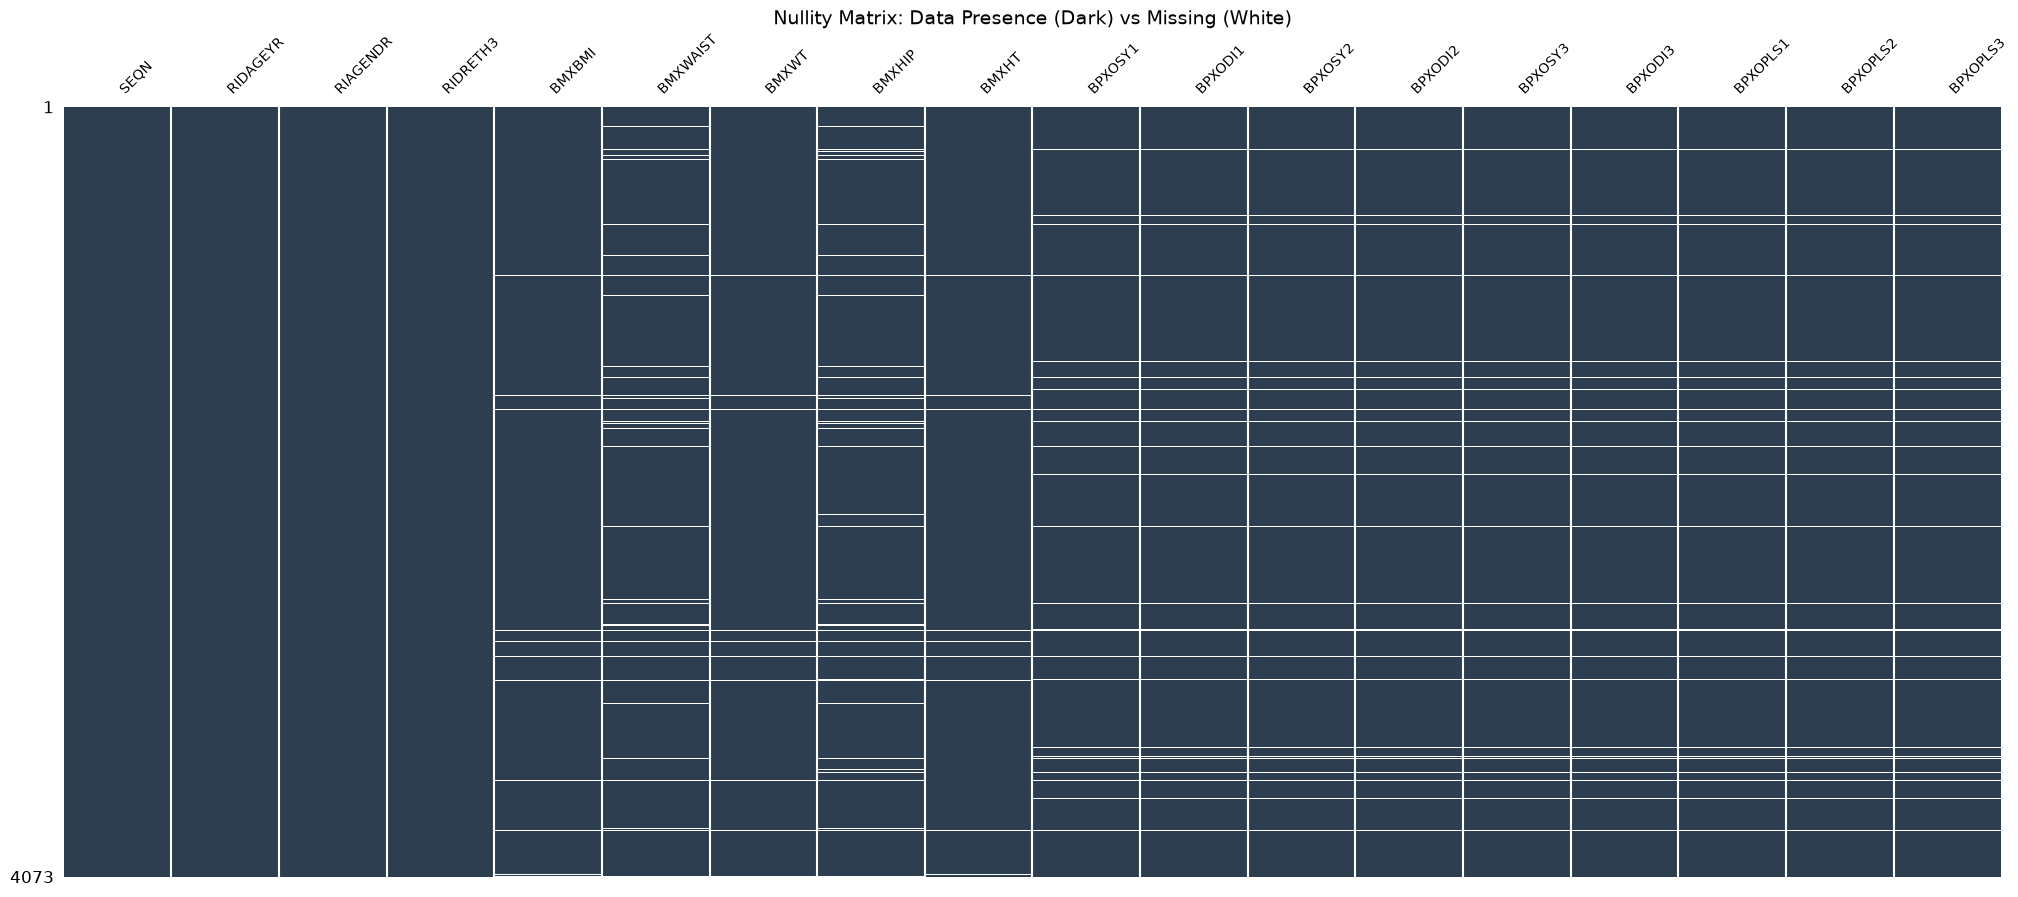

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

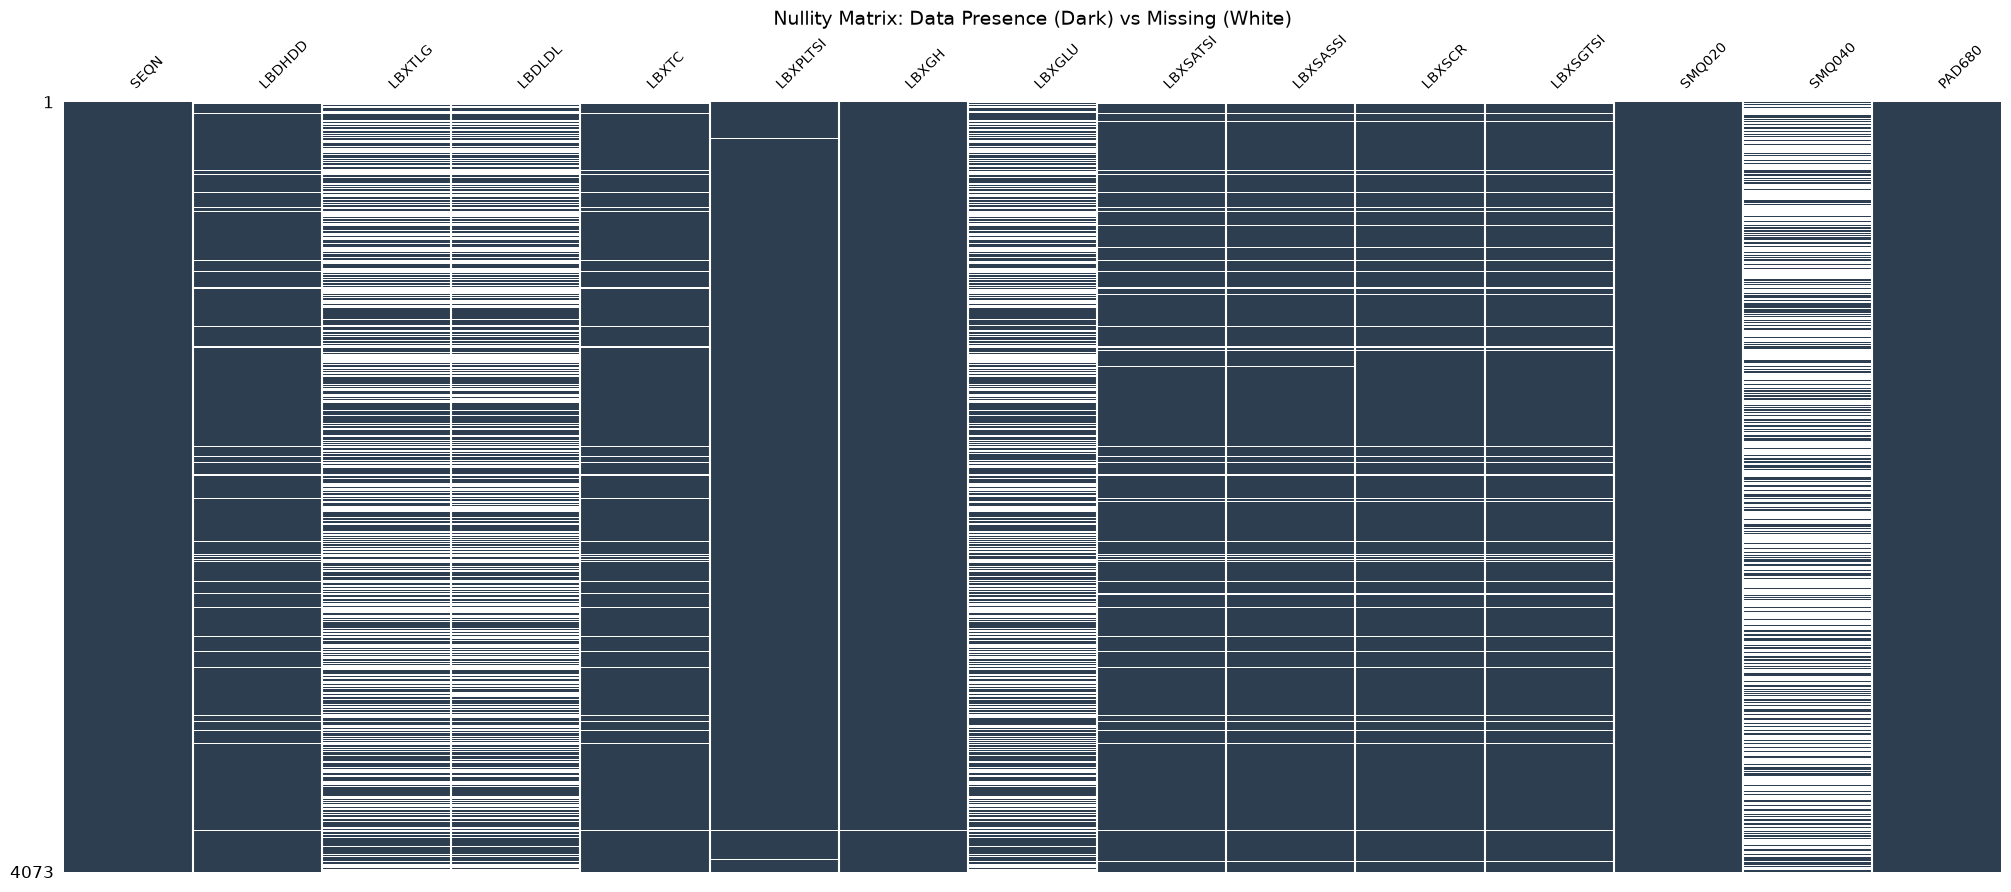

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

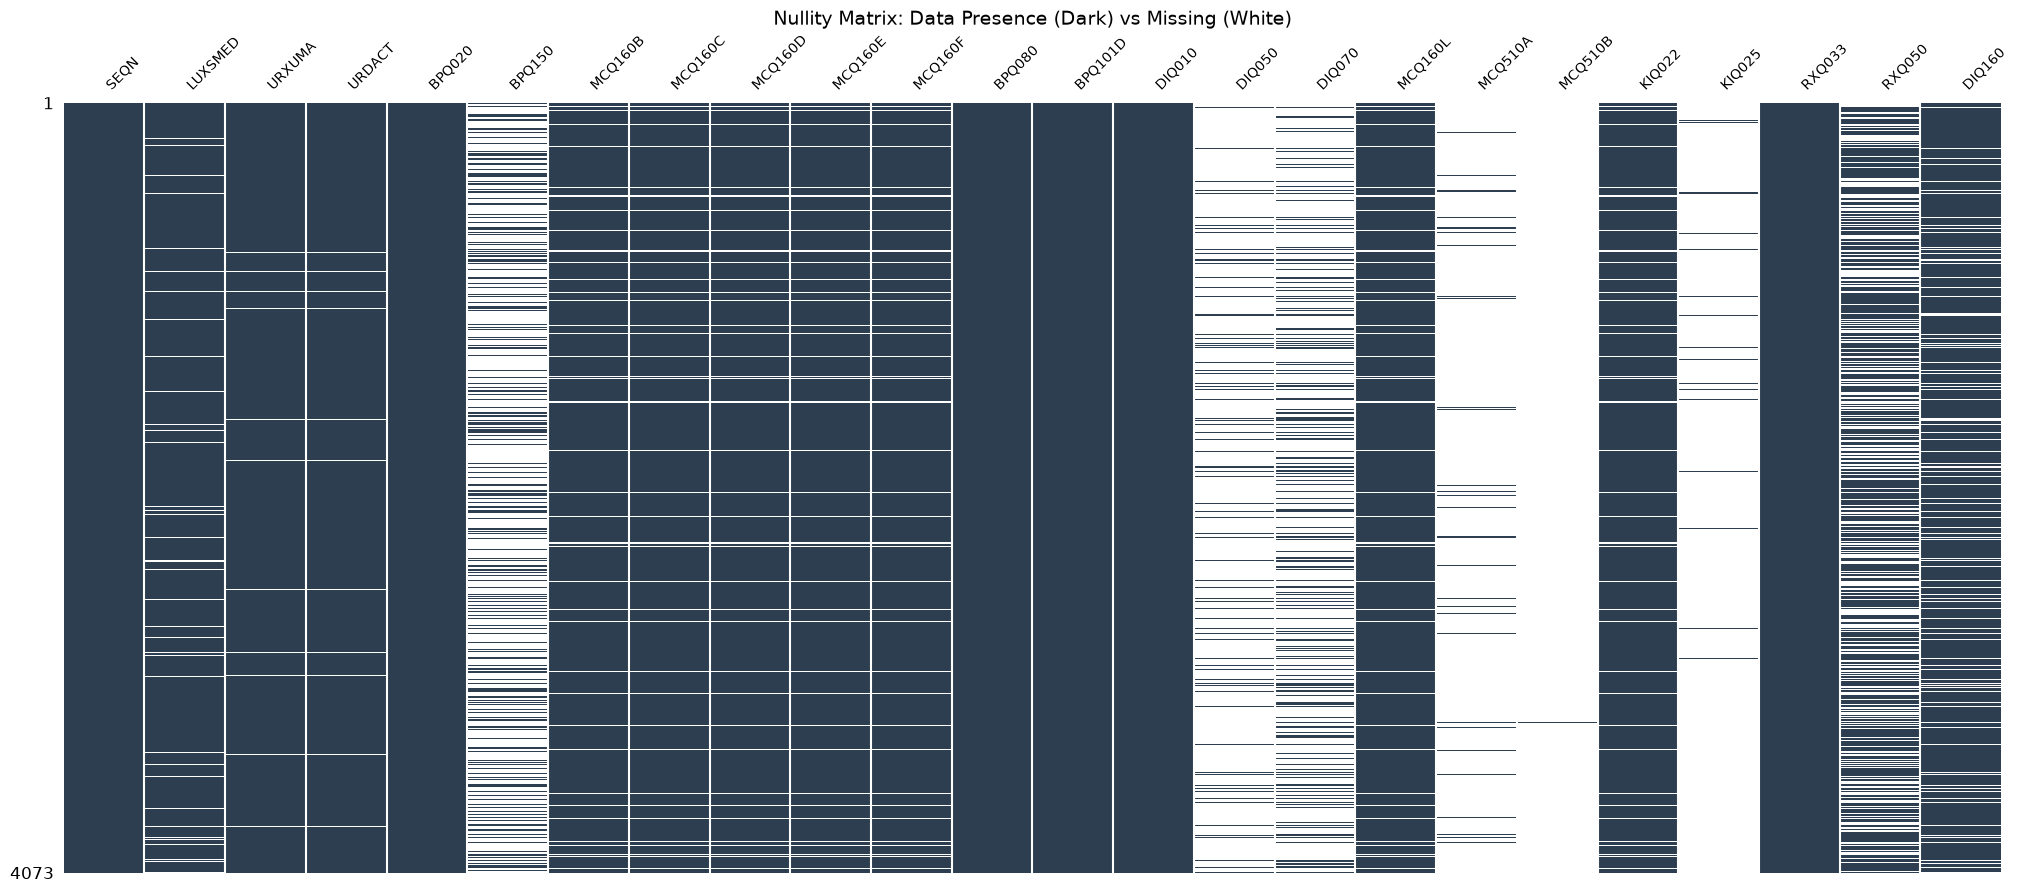

In [10]:
auditor.visualize_nullity(target_columns=demographics)
auditor.visualize_nullity(target_columns=labs_questions)
auditor.visualize_nullity(target_columns=organ_damage)

### 🛠️ Programmatic Optimization via Deterministic Parental Imputation
---
To address these logical skips without introducing artificial bias, we use a custom Python `Imputer` class.

Instead of relying on statistical averages like mean or mode imputation, our `Imputer` applies clinical logic:

$$\text{If } \text{Parent\_Column} \in \text{Trigger\_Value} \implies \text{Child\_Column} \colonequals \text{Logical\_Default}$$

This method programmatically restores structural missingness, preserving key data points for our analysis:

*   **Smoking Profile (`SMQ020`** $\to$ **`SMQ040`):** If a patient has not smoked 100+ cigarettes, their current smoking frequency (`SMQ040`) is programmatically set to `3.0` ("Not at all").
*   **Hypertension Profile (`BPQ020`** $\to$ **`BPQ150`):** If a patient has no history of hypertension, their medication usage (`BPQ150`) is programmatically set to `2.0` ("No").
*   **Diabetes Profile (`DIQ010`** $\to$ **`DIQ050`, `DIQ070`):** If a patient has no history of diabetes, follow-up fields for insulin and oral medication are set to `2.0` ("No").
*   **Hepatic Profile (`MCQ160L`** $\to$ **`MCQ510A`, `MCQ510B`):** If a patient has no history of liver disease, fatty liver and fibrosis flags are resolved to `0.0` (absence of condition).
*   **Renal Profile (`KIQ022`** $\to$ **`KIQ025`):** If a patient has no history of kidney failure, their dialysis history is resolved to `2.0` ("No").

This process ensures that our final cohort remains clean and structurally complete for downstream metabolic modeling.

In [11]:
imputed_dataset = (
    Imputer(processed_dataset)
    .structural_skips()
    )

Imputation [SMQ020 -> SMQ040]: Rescued 2609 structural records.
Imputation [BPQ020 -> BPQ150]: Rescued 2971 structural records.
Imputation [DIQ010 -> DIQ050]: Rescued 3663 structural records.
Imputation [DIQ010 -> DIQ070]: Rescued 3128 structural records.
Imputation [MCQ160L -> MCQ510A]: Rescued 3613 structural records.
Imputation [MCQ160L -> MCQ510B]: Rescued 3613 structural records.
Imputation [KIQ022 -> KIQ025]: Rescued 3750 structural records.


In [12]:
# Instantiate the audit engine by explicitly passing your data and loader metadata
auditor = Auditor(imputed_dataset, metadata_storage=loader.metadata_storage)

# Run the execution layer and capture the full dataframe output
missing_data_summary = auditor.column_missingness(head_count= 20)

,Variable_Code,Clinical_Label,Missing_Count,Missing_Percentage
0,LBDLDL,"LDL-Cholesterol, Friedewald (mg/dL)",1970,48.367297
1,LBXTLG,Triglyceride (mg/dL),1939,47.606187
2,LBXGLU,Fasting Glucose (mg/dL),1847,45.347410
3,WTSAF2YR,Fasting Subsample 2 Year MEC Weight,1803,44.267125
4,RXQ050,Number of prescription medicines taken,1658,40.707096
5,DIQ160,Ever told you have prediabetes,529,12.987970
6,MCQ510B,Liver condition: Liver fibrosis,457,11.220231
7,MCQ510A,Liver condition: Fatty liver,328,8.053032
8,LBXSASSI,Aspartate Aminotransferase (AST) (IU/L),262,6.432605
9,LBXSATSI,Alanine Aminotransferase (ALT) (IU/L),254,6.236190


Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

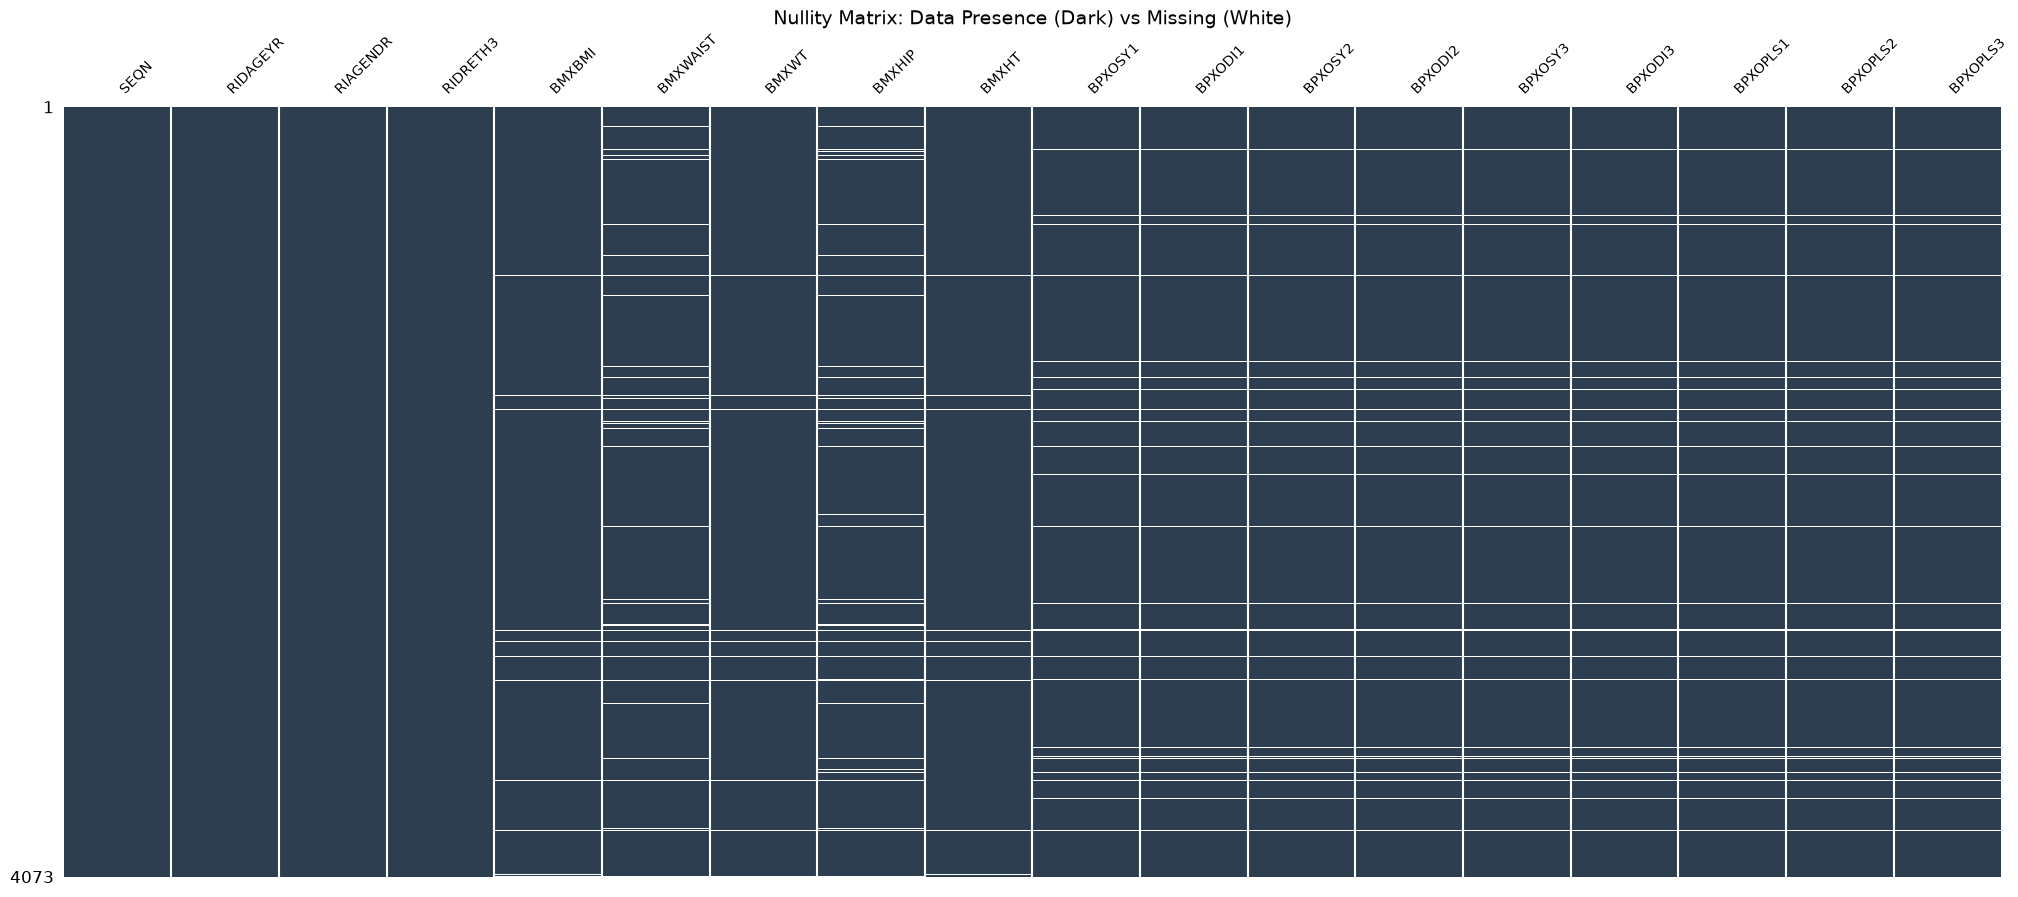

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

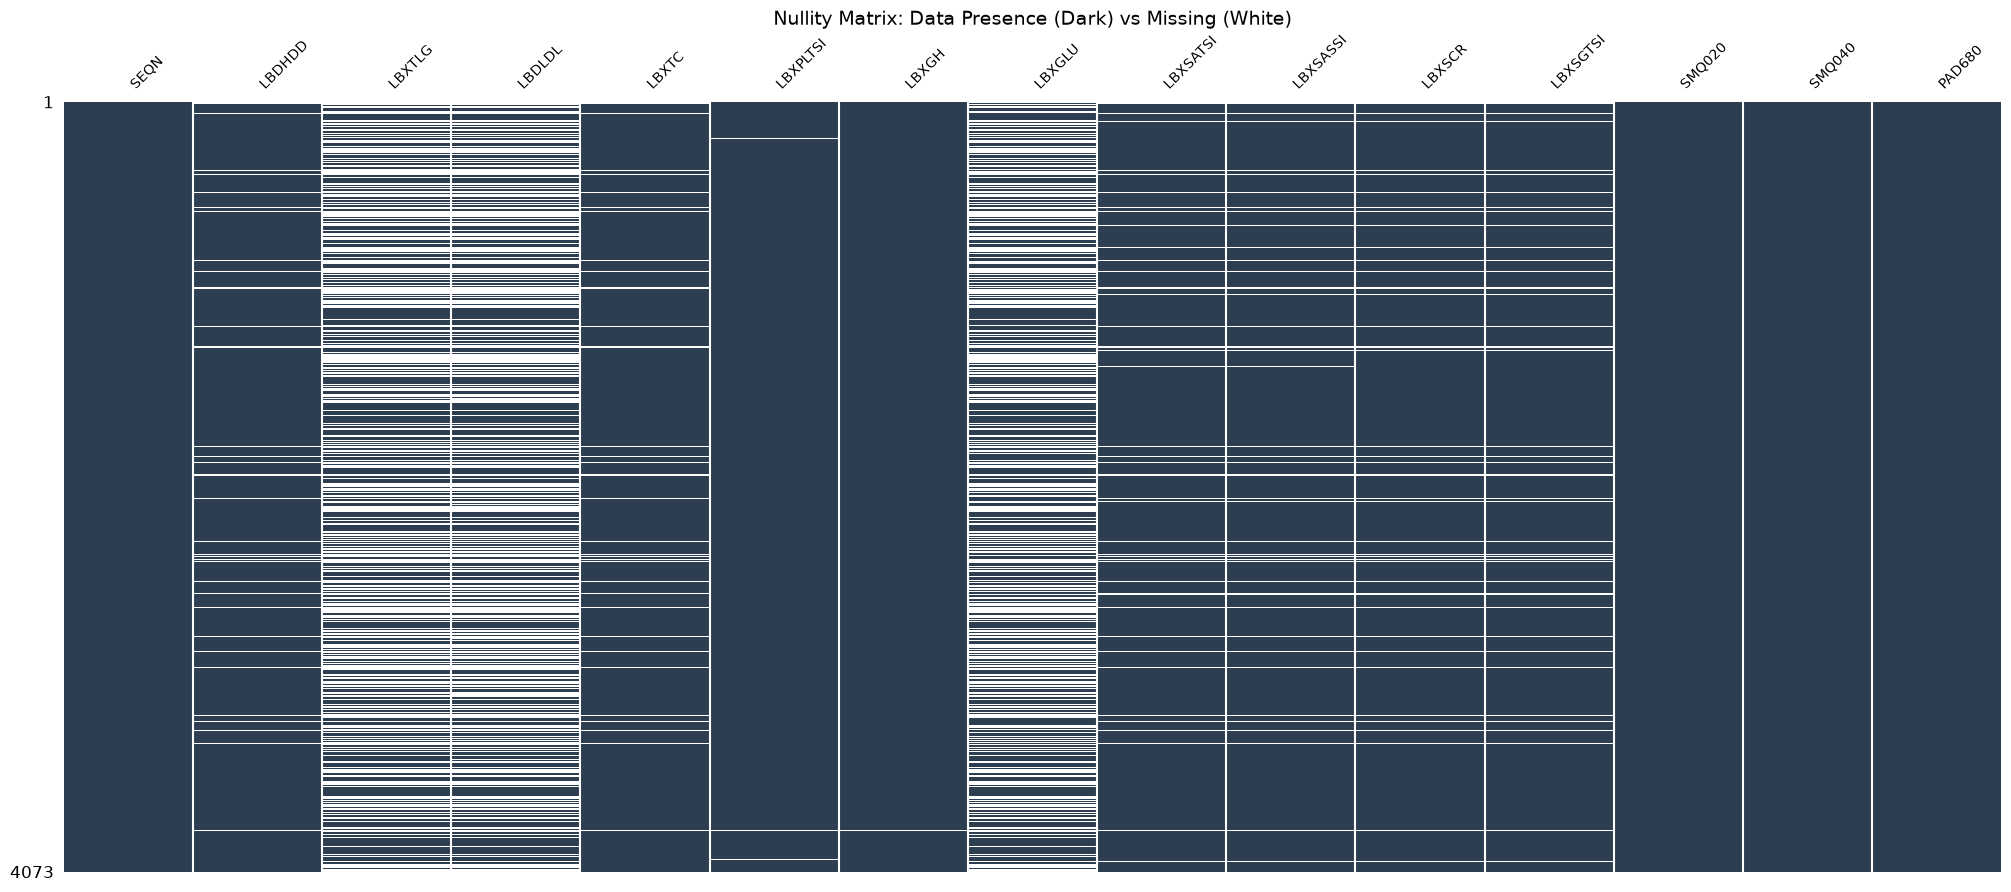

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

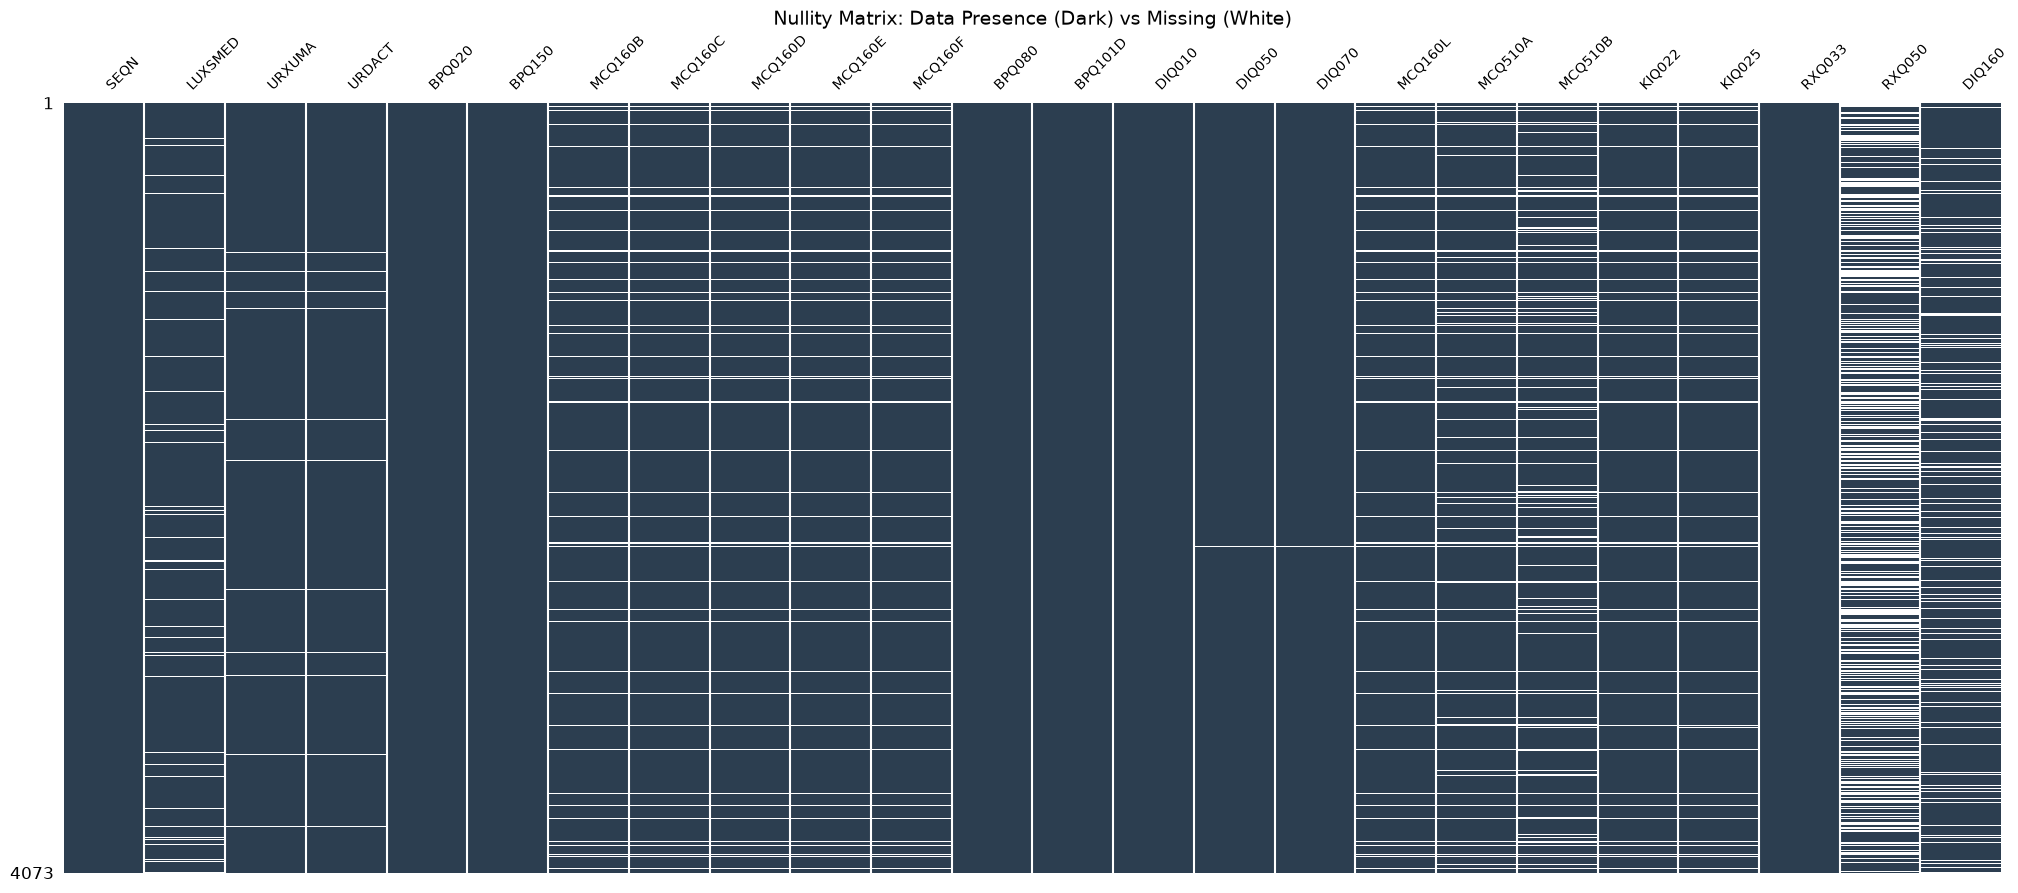

In [13]:
auditor.visualize_nullity(target_columns=demographics)
auditor.visualize_nullity(target_columns=labs_questions)
auditor.visualize_nullity(target_columns=organ_damage)

In [14]:
# # NHANES metadata map directly inside the dataframe attributes
# imputed_dataset.attrs['clinical_metadata'] = loader.metadata_storage

In [15]:
# # Export the cohort while embedding the metadata
# imputed_dataset.to_parquet(
#     '../outputs/nhanes_processed_cohort.parquet', 
#     engine='pyarrow', 
#     compression='snappy'
# )

In [16]:
# # Load the dataset back into memory
# loaded_df = pd.read_parquet('../outputs/nhanes_processed_cohort.parquet')

# # Extract and inspect your clinical label mapping
# saved_metadata = loaded_df.attrs.get('clinical_metadata')

# # Quick test to see it worked
# print(type(saved_metadata))  # Output: <class 'dict'>